In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize


In [12]:
# === Parameters ===
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
BASE_DIR = Path.cwd()
TEST_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "test"

# === Data Generators ===
# Custom model has Rescaling(1./255) built-in, so no preprocessing function needed
test_datagen_custom = ImageDataGenerator(rescale=1.0 / 255)

test_generator_custom = test_datagen_custom.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# VGG16 preprocessing
test_datagen_vgg16 = ImageDataGenerator(preprocessing_function=preprocess_vgg16)
test_generator_vgg16 = test_datagen_vgg16.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# MobileNetV2 preprocessing
test_datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_mobilenetv2)
test_generator_mobilenet = test_datagen_mobilenet.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

class_names = list(test_generator_custom.class_indices.keys())


Found 2627 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.


In [13]:
# === Load Models ===
print("Cargando modelo VGG16...")
model_vgg16 = load_model("mejor_modelo_VGG16.keras")
print("Cargando modelo Custom...")
model_custom = load_model("mejor_modelo_CM.keras")

print("Cargando modelo MobileNetV2...")
model_mobilenet = load_model("mejor_modelo_MBNet.keras")



Cargando modelo VGG16...
Cargando modelo Custom...
Cargando modelo MobileNetV2...


In [14]:
model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_mobilenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [15]:
# === Evaluate Models ===
print("\nEvaluando modelo Custom...")
loss_custom, acc_custom = model_custom.evaluate(test_generator_custom, verbose=1)

print("\nEvaluando modelo VGG16...")
loss_vgg16, acc_vgg16 = model_vgg16.evaluate(test_generator_vgg16, verbose=1)

print("\nEvaluando modelo MobileNetV2...")
loss_mobilenet, acc_mobilenet = model_mobilenet.evaluate(test_generator_mobilenet, verbose=1)

print("\n=== Resultados de Evaluación en Test ===")
print(f"Custom      - Accuracy: {acc_custom:.4f}, Loss: {loss_custom:.4f}")
print(f"VGG16       - Accuracy: {acc_vgg16:.4f}, Loss: {loss_vgg16:.4f}")
print(f"MobileNetV2       - Accuracy: {acc_mobilenet:.4f}, Loss: {loss_mobilenet:.4f}")


Evaluando modelo Custom...
83/83 [==============================] - 5s 56ms/step - loss: 0.8774 - accuracy: 0.7168

Evaluando modelo VGG16...
83/83 [==============================] - 25s 300ms/step - loss: 0.1417 - accuracy: 0.9612

Evaluando modelo MobileNetV2...
83/83 [==============================] - 8s 79ms/step - loss: 0.1414 - accuracy: 0.9558

=== Resultados de Evaluación en Test ===
Custom      - Accuracy: 0.7168, Loss: 0.8774
VGG16       - Accuracy: 0.9612, Loss: 0.1417
MobileNetV2       - Accuracy: 0.9558, Loss: 0.1414


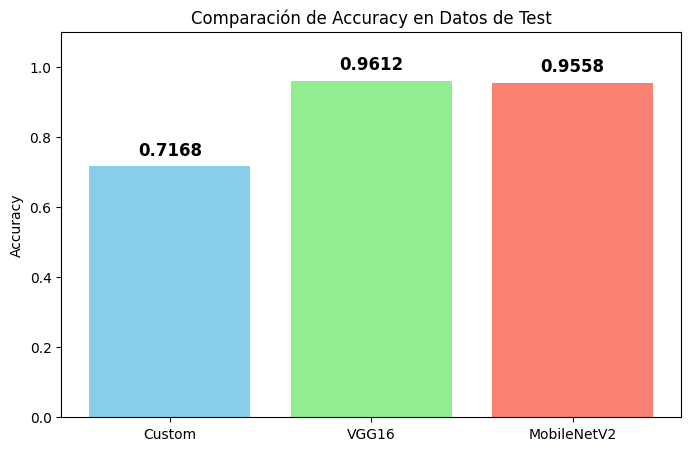

In [16]:
# === Graph Accuracy Comparison ===
models = ['Custom', 'VGG16', 'MobileNetV2']
accuracies = [acc_custom, acc_vgg16, acc_mobilenet]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1.1)
plt.title('Comparación de Accuracy en Datos de Test')
plt.ylabel('Accuracy')

# Añadir etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')




Evaluando Custom Model...
83/83 [==============================] - 5s 60ms/step


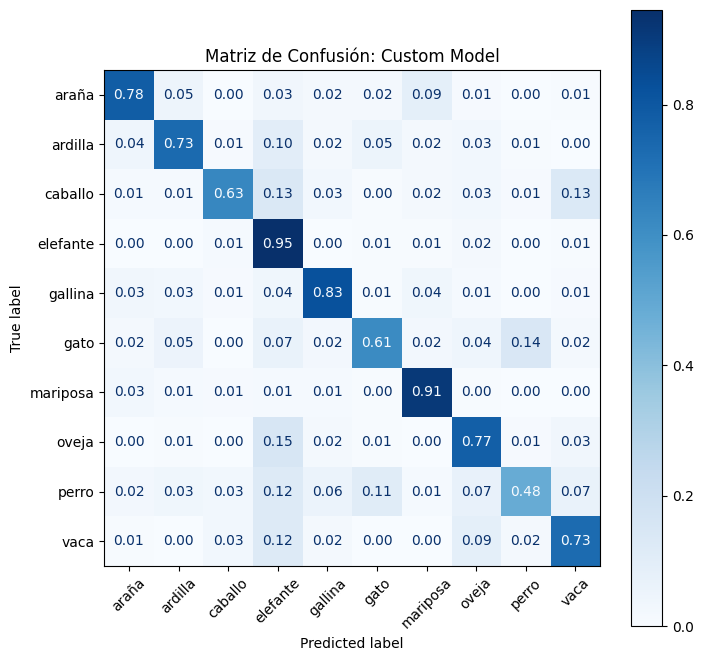


Classification Report: Custom Model

              precision    recall  f1-score   support

       araña       0.90      0.78      0.83       483
     ardilla       0.68      0.73      0.71       187
     caballo       0.86      0.63      0.73       263
    elefante       0.41      0.95      0.57       146
     gallina       0.81      0.83      0.82       311
        gato       0.58      0.61      0.59       168
    mariposa       0.73      0.91      0.81       212
       oveja       0.63      0.77      0.70       182
       perro       0.87      0.48      0.62       487
        vaca       0.63      0.73      0.67       188

    accuracy                           0.72      2627
   macro avg       0.71      0.74      0.70      2627
weighted avg       0.76      0.72      0.72      2627



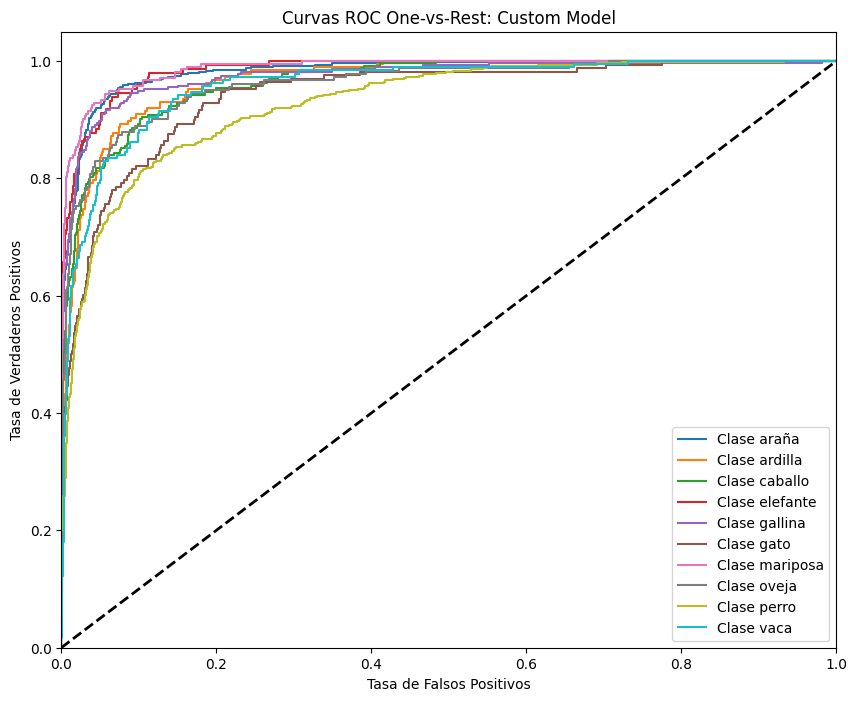


Evaluando VGG16...
83/83 [==============================] - 25s 303ms/step


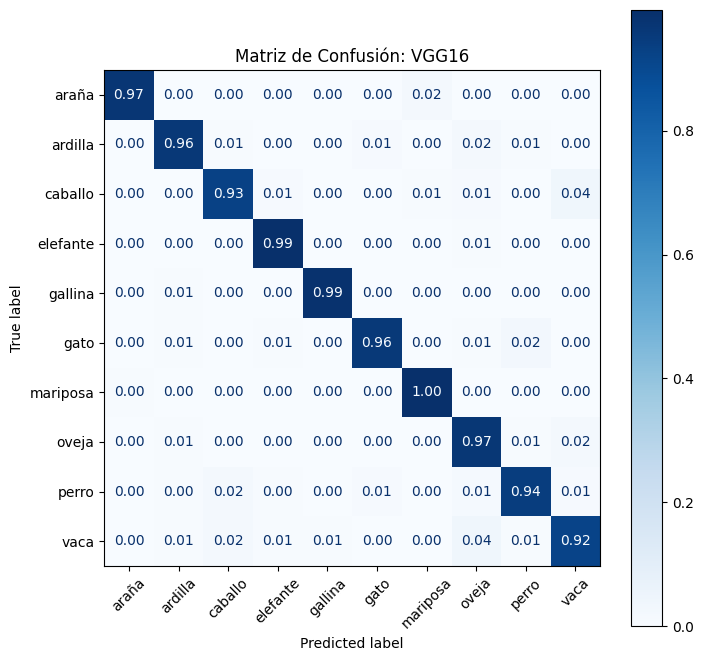


Classification Report: VGG16

              precision    recall  f1-score   support

       araña       1.00      0.97      0.98       483
     ardilla       0.96      0.96      0.96       187
     caballo       0.95      0.93      0.94       263
    elefante       0.95      0.99      0.97       146
     gallina       0.99      0.99      0.99       311
        gato       0.95      0.96      0.96       168
    mariposa       0.94      1.00      0.97       212
       oveja       0.89      0.97      0.93       182
       perro       0.98      0.94      0.96       487
        vaca       0.90      0.92      0.91       188

    accuracy                           0.96      2627
   macro avg       0.95      0.96      0.96      2627
weighted avg       0.96      0.96      0.96      2627



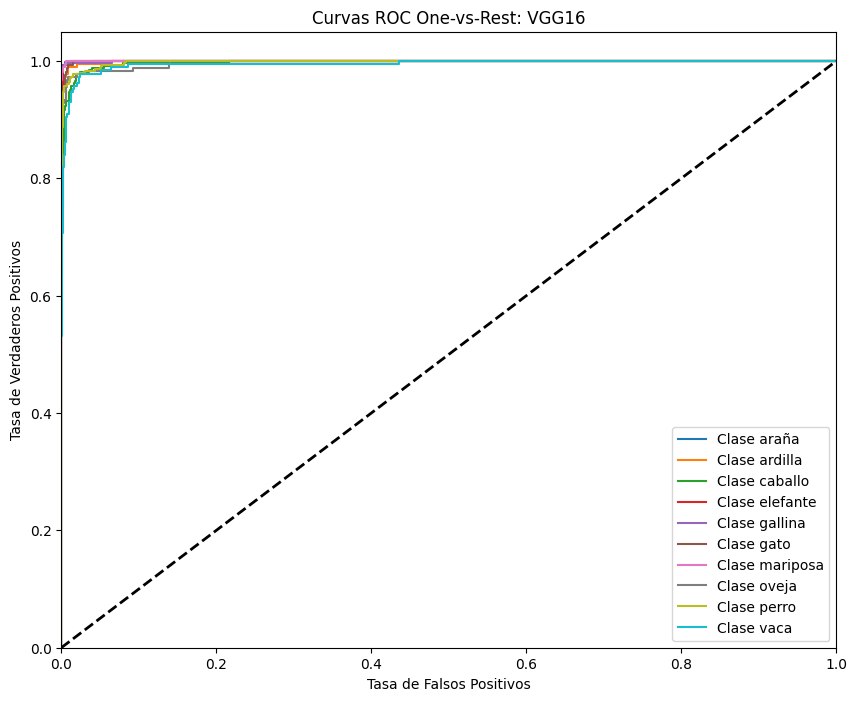


Evaluando MobileNetV2...
83/83 [==============================] - 7s 75ms/step


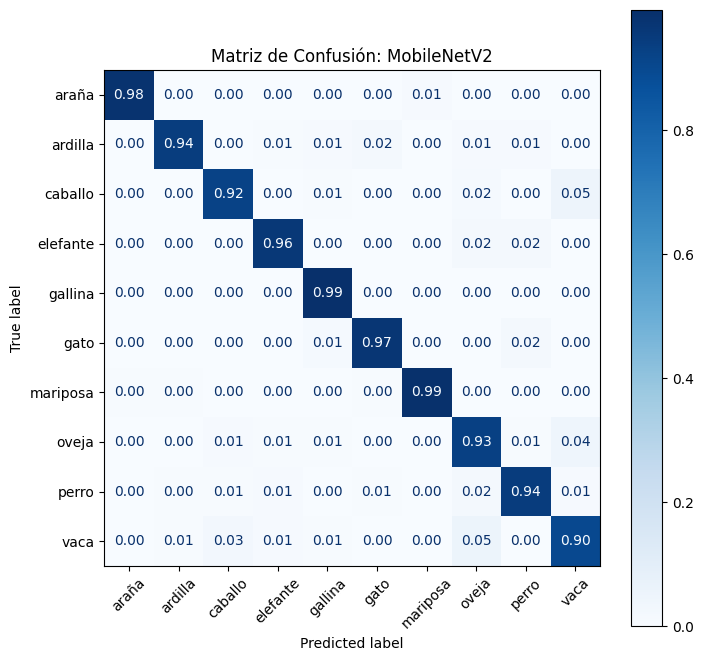


Classification Report: MobileNetV2

              precision    recall  f1-score   support

       araña       1.00      0.98      0.99       483
     ardilla       0.97      0.94      0.96       187
     caballo       0.96      0.92      0.94       263
    elefante       0.93      0.96      0.95       146
     gallina       0.97      0.99      0.98       311
        gato       0.95      0.97      0.96       168
    mariposa       0.97      0.99      0.98       212
       oveja       0.86      0.93      0.89       182
       perro       0.98      0.94      0.96       487
        vaca       0.87      0.90      0.88       188

    accuracy                           0.96      2627
   macro avg       0.95      0.95      0.95      2627
weighted avg       0.96      0.96      0.96      2627



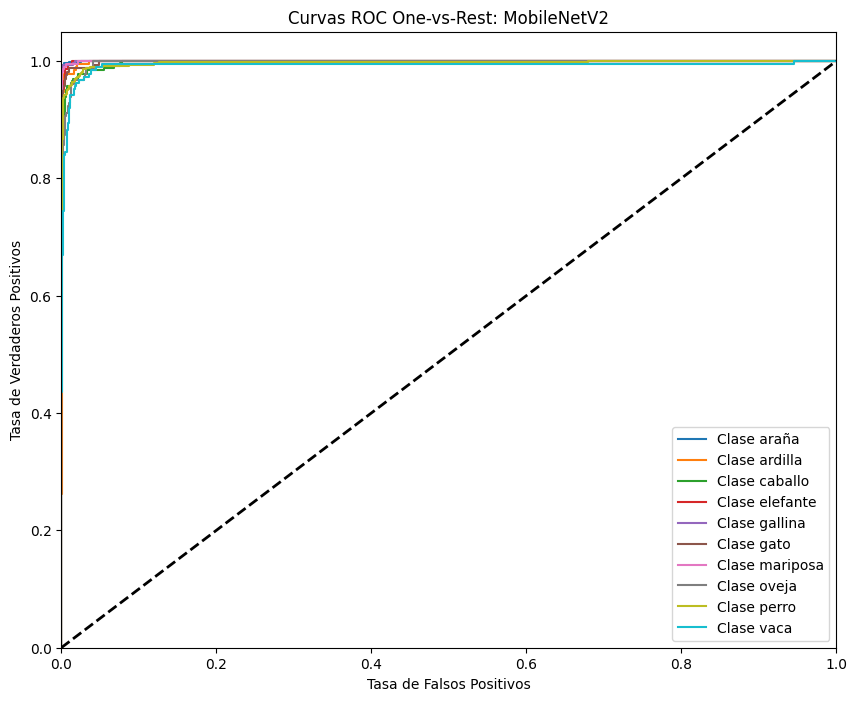

In [17]:
# === Evaluación Avanzada y Matrices de Confusión ===
# Priorizamos F1-Score Macro debido a que es una clasificación multiclase donde cada imagen 
# corresponde a una única especie de pez, permitiendo una métrica robusta ante posibles desbalances.

def evaluate_model_advanced(model, generator, title, class_names):
    print(f"\n{'='*50}")
    print(f"Evaluando {title}...")
    print(f"{'='*50}")
    
    generator.reset()
    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred,normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45, values_format='.2f')
    plt.title(f'Matriz de Confusión: {title}')
    plt.show()
    
    # Classification Report
    print(f"\nClassification Report: {title}\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    metrics = {'Model': title}
    
    # Accuracy
    try:
        metrics['Accuracy'] = accuracy_score(y_true, y_pred)
    except Exception:
        metrics['Accuracy'] = np.nan
        
    # Precision Macro
    try:
        metrics['Precision Macro'] = precision_score(y_true, y_pred, average='macro')
    except Exception:
        metrics['Precision Macro'] = np.nan

    # Recall Macro
    try:
        metrics['Recall Macro'] = recall_score(y_true, y_pred, average='macro')
    except Exception:
        metrics['Recall Macro'] = np.nan

    # F1 Macro
    try:
        metrics['F1 Macro'] = f1_score(y_true, y_pred, average='macro')
    except Exception:
        metrics['F1 Macro'] = np.nan

    # Specificity Macro
    try:
        # Specificity = TN / (TN + FP)
        # Per class specificity
        specificity_list = []
        for i in range(len(class_names)):
            tn = np.sum(np.delete(np.delete(cm, i, 0), i, 1))
            fp = np.sum(cm[:, i]) - cm[i, i]
            specificity_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        metrics['Specificity'] = np.mean(specificity_list)
    except Exception:
        metrics['Specificity'] = np.nan

    # ROC-AUC
    try:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
        n_classes = y_true_bin.shape[1]
        
        # Calculate ROC-AUC One-vs-Rest
        metrics['ROC-AUC'] = roc_auc_score(y_true_bin, preds, multi_class='ovr')
        
        # Plot ROC curves
        plt.figure(figsize=(10, 8))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], preds[:, i])
            plt.plot(fpr, tpr, label=f'Clase {class_names[i]}')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Tasa de Falsos Positivos')
        plt.ylabel('Tasa de Verdaderos Positivos')
        plt.title(f'Curvas ROC One-vs-Rest: {title}')
        plt.legend(loc="lower right")
        plt.show()
    except Exception:
        metrics['ROC-AUC'] = np.nan
        print(f"No se pudo calcular ROC-AUC para {title}.")

    return metrics

results = []
results.append(evaluate_model_advanced(model_custom, test_generator_custom, "Custom Model", class_names))
results.append(evaluate_model_advanced(model_vgg16, test_generator_vgg16, "VGG16", class_names))
results.append(evaluate_model_advanced(model_mobilenet, test_generator_mobilenet, "MobileNetV2", class_names))



In [18]:
# === Comparación Consolidada ===

df_results = pd.DataFrame(results)

# Renombrar columnas según lo solicitado
df_results = df_results.rename(columns={'Model': 'Modelo'})

print("\nTabla Comparativa de Modelos:")
display(df_results)


Tabla Comparativa de Modelos:


,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,Specificity,ROC-AUC
0,Custom Model,0.716787,0.708365,0.742332,0.704500,0.971370,0.965286
1,VGG16,0.961172,0.951168,0.962499,0.956469,0.995833,0.998544
2,MobileNetV2,0.955843,0.945205,0.952332,0.948444,0.994704,0.998188
